## Problem 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 2
Omega_ss = 2*np.pi/365/(24*3600)
print(Omega_ss)
mu = 398600
J2 = 1.08263e-3
R0 = 6378
am = (3/2*J2*R0**2*np.sqrt(mu))/Omega_ss
print(f'am = {am}')

def inc(a):
    """ 
    Calculate inclination as a function of radius
    """
    i = np.arccos(-a/am)
    return i

a = np.linspace(6400,am,1000)
i = [inc(x) for x in a]
i = [x*180/np.pi for x in i]

plt.plot(a,i)
plt.grid()
plt.xlabel('Semimajor Axis (km)')
plt.ylabel('Inclination (deg)')
plt.title('Inclination vs Semimajor Axis')
plt.show()

Tmax = 2*np.pi/np.sqrt(mu)*am**(3/2)
Tmin = 2*np.pi/np.sqrt(mu)*R0**(3/2)

print(f'Tmax = {Tmax} s, Tmin = {Tmin}')


In [ ]:
# Problem 1.d
import numpy as np
from orbit_package.orbit_package import Orbit
orb = Orbit()

T = 12 # hrs
T = 12*3600 # s
omega = -np.pi/2
mu = 398600 #km^3/s^2
J2 = 1.08263e-3
R = 6378
rp = 7000 #km

# Finding SMA from T
a = (T*np.sqrt(mu)/(2*np.pi))**(2/3)

# Finding eccentricity
e = 1-rp/a

# Finding orbit rate
cosi = 1/np.sqrt(5)
Omega = -3/2*np.sqrt(mu)*J2*R**2/(1-e**2)**2/a**(7/2)*cosi
print(f'Omega_dot = {Omega} rad/s = {Omega*180/np.pi*(3600*24)} deg/day')

# Part ii: Percent of time in northern hemisphere
f1 = np.pi/2
f2 = 3*np.pi/2

t = orb.tof_two_nu(f1,f2,a,e,mu)
print(f'Time in northern hemisphere: t = {t} s')
print(f'Time in southern hemisphere: t = {T - t} s')
print(f'Percentage of time in Norhern Hemisphere: {t/T*100}%')

# Part iii: argp drift
i = np.arctan2(2/np.sqrt(5),1/np.sqrt(5))
i = i - 0.5*np.pi/180
omega_dot = -3/2*(np.sqrt(mu)*J2*R**2)/((1-e**2)**2*a**(7/2))*(5/2*np.sin(i)**2 - 2)
t_drift = np.pi/omega_dot
print(f't_drift = {t_drift} s = {t_drift/3600/24/365} years')

In [ ]:
# Probem 1.e
import numpy as np
from orbit_package.orbit_package import Orbit
orb = Orbit()
import matplotlib.pyplot as plt

# Givens
e = 0
a = 6578
mu = 398600
n = np.sqrt(mu/a**3)
J2 = 1.08263e-3
R = 6378

i_list = [0,np.pi/2]

for i in i_list:
    print('')
    print(f'i = {i} rad: ')
    pv = orb.j2_perturbation(e,i,a)
    print(pv)

    # Finding radial difference solutions
    dn = np.abs(pv['n'] - pv['nbar'])  
    print(f'dn = {dn}')
    
    # time to separate by pi rad
    t = np.pi/dn
    print(f'The orbits will be separated 180deg after {t} seconds = {t/3600/24} days')

    # AT distance between them
    T = 2*np.pi/np.sqrt(mu)*a**(3/2)
    df = T*dn

    dr = df*a
    print(f'df = {df} rad, dr_at = {dr} km')






## Problem 2

### Part a) Implement J2 effect in the numerical propagator

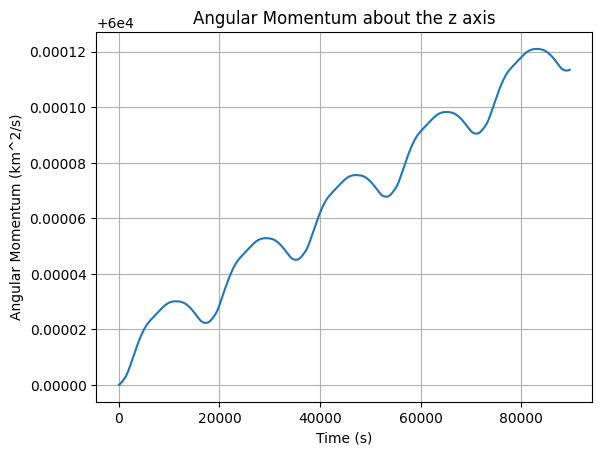

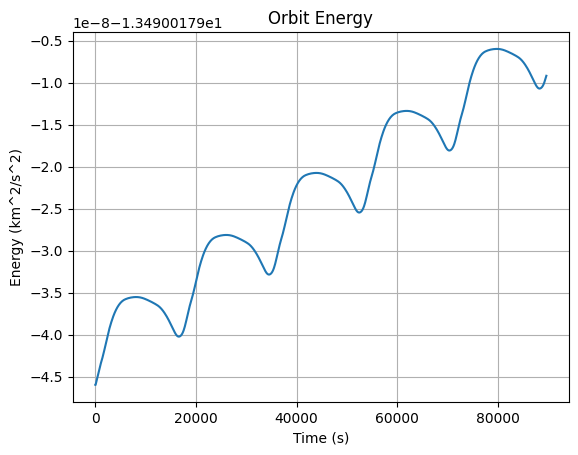

In [ ]:
import numpy as np
from orbit_package.numerical import Integrator, ForcingFunction
from orbit_package.graphing_utils import Graph
from orbit_package.ephemeris import Ephemeris
from orbit_package.orbit_package import Orbit

# Instantiating all obejects
integrate = Integrator()
ff = ForcingFunction()
gr = Graph()
orb = Orbit()

# Initial conditions and parameters
x0 = np.array([6e3,6e3,6e3,-5,5,0])
other = {"mu":4e5,"J2":1.08263e-3,"R":6378}
period = 17933.95497
tspan = [0,5*period]
integration_time = np.linspace(0,2*int(period),int(2*int(period)/60))

# Integrating
t,x = integrate.ode45(ff.twobody_j2_nodyn,x0,tspan,other)

eph = integrate.eph_from_propagation_results(t,x,"2BODY_J2")
eph = orb.fill_eph_osculating(eph,other['mu'])

gr.plot_eph_osc(eph,other['mu'])
gr.plot_eph_pos_vector(eph,earth=True)

# Determining that the following are constant
# Angular Momentum about the z axis:
hvecs = eph.all_h_osc()
z = np.array([0,0,1])
hz = [np.dot(hvec,z) for hvec in hvecs]
import matplotlib.pyplot as plt
plt.plot(t,hz,label = 'Angular Momentum')
plt.grid()
plt.title('Angular Momentum about the z axis')
plt.xlabel('Time (s)')
plt.ylabel('Angular Momentum (km^2/s)')
plt.show()

# Enery
vlist = eph.all_v_norm()
rlist = eph.all_r_norm()
zlist = eph.all_z()
E = []
for i in range(len(eph.data)):
    E.append(1/2*vlist[i]**2 - other['mu']/rlist[i] - other['mu']/(2*rlist[i]**3)*other['R']**2*other['J2']*(1-3*zlist[i]**2/rlist[i]**2))

plt.plot(t,E,label='Energy')
plt.grid()
plt.title('Orbit Energy')
plt.xlabel('Time (s)')
plt.ylabel('Energy (km^2/s^2)')
plt.show()

### Implementing the updated code to propagate an orbit under J2 perturbation

In [ ]:
import numpy as np
from orbit_package.numerical import Integrator, ForcingFunction
from orbit_package.graphing_utils import Graph
from orbit_package.ephemeris import Ephemeris
from orbit_package.orbit_package import Orbit

# Instantiating all obejects
integrate = Integrator()
ff = ForcingFunction()
gr = Graph()
orb = Orbit()

# Initial conditions and parameters
a = 7000
e = 0.1
i = np.pi/4
omega = 0
Omega = 0
sigma = 0
mu = 398600
T = 2*np.pi*a**(3/2)/np.sqrt(mu)
n = np.sqrt(mu/a**3)
elements = {'sma':a,'ecc':e,'argp':omega,'raan':Omega,'inc':i,'nu':0,'E':0}

r,v = orb.kep_to_cart(elements,mu)
tspan = [0,5*T]

x0 = np.concat([r,v])
# Integrating
other = {"mu":4e5,"J2":1.08263e-3,"R":6378}
t,x = integrate.ode45(ff.twobody_j2_nodyn,x0,tspan,other)

eph = integrate.eph_from_propagation_results(t,x,"2BODY_J2")
eph = orb.fill_eph_osculating(eph,other['mu'])

# Determining that the following are constant
# Angular Momentum about the z axis:
hvecs = eph.all_h_osc()
z = np.array([0,0,1])
hz = [np.dot(hvec,z) for hvec in hvecs]
import matplotlib.pyplot as plt
# plt.plot(t,hz,label = 'Angular Momentum')
# plt.grid()
# plt.title('Angular Momentum about the z axis')
# plt.xlabel('Time (s)')
# plt.ylabel('Angular Momentum (km^2/s)')


# Enery
vlist = eph.all_v_norm()
rlist = eph.all_r_norm()
zlist = eph.all_z()
E = []
for i in range(len(eph.data)):
    E.append(1/2*vlist[i]**2 - other['mu']/rlist[i] - other['mu']/(2*rlist[i]**3)*other['R']**2*other['J2']*(1-3*zlist[i]**2/rlist[i]**2))
i = np.pi/4
# plt.plot(t,E,label='Energy')
# plt.grid()
# plt.title('Orbit Energy')
# plt.xlabel('Time (s)')
# plt.ylabel('Energy (km^2/s^2)')


# Propagating using LPE (averaging)
dt = np.linspace(0,5*T,1000)
alpha0 = {'a0':a,'e0':e,'i0':i,'omega0':omega,'Omega0':Omega,'M0':0,'n0':n}
eph = orb.lpe_propagation_J2(alpha0,dt,mu,other['J2'],other['R'])
print('bork')